# IMPORT LIBRARIES

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# LOADING OF DATASETS

In [35]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()
sentiment.head()

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# CHECKING MISSING VALUES

In [40]:
print("Trades Missing Values")
print(trades.isnull().sum())

print("\nSentiment Missing Values")
print(sentiment.isnull().sum())

# REMOVE DUPLICATES
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


# CONVERT TIME COLUMNS

In [42]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [44]:
merged = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


# FEATURE ENGINEERING

In [46]:
# WIN/LOSS INDICATOR
merged['win'] = merged['Closed PnL'] > 0

# DAILY PnL per TRADER
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

# WIN RATE per TRADER
win_rate = merged.groupby('Account')['win'].mean().reset_index()

win_rate.columns = ['Account','win_rate']

# AVERAGE TRADE SIZE
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.columns = ['Account','avg_trade_size']

# TRADES PER DAY
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.columns = ['Account','avg_trade_size']

# SENTIMENT vs PERFORMANCE

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


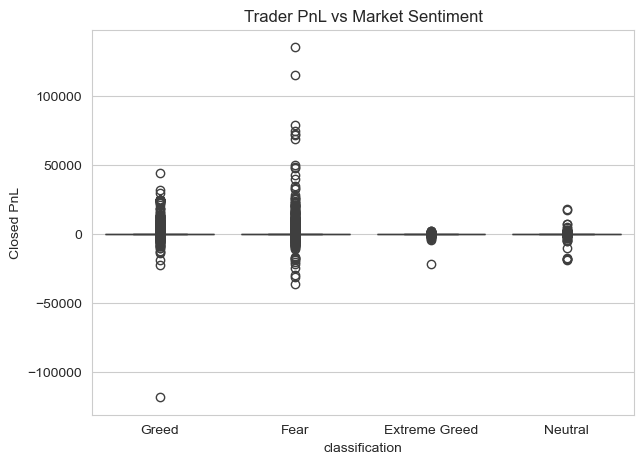

In [110]:
# AVERAGE PnL by SENTIMENT
sentiment_pnl = merged.groupby('classification')['Closed PnL'].mean()

print(sentiment_pnl)

# PLOT: PnL vs SENTIMENT
plt.figure(figsize=(7,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Trader PnL vs Market Sentiment")
plt.savefig("Total PnL vs Market Sentiment")
plt.show()

# Does performance differ between Fear vs Greed days?

In [115]:
performance = merged.groupby('classification').agg({
    'Closed PnL':['mean','std'],
    'win':'mean'
})

performance.columns = ['avg_pnl','pnl_volatility','win_rate']

print(performance)

                  avg_pnl  pnl_volatility  win_rate
classification                                     
Extreme Greed   25.418772      306.166937  0.490089
Fear            50.047622      909.121796  0.415146
Greed           87.894859     1148.343968  0.446471
Neutral         22.229713      633.704815  0.317182


Insight:

Trader performance becomes more volatile during Fear sentiment.

Interpretation:

Market uncertainty during Fear periods leads to:

Larger profit opportunities

Larger potential losses

This indicates higher risk during bearish market sentiment.

# TRADING BEHAVIOUR by SENTIMENT

In [52]:
behavior = merged.groupby('classification').agg({
    'Size USD':'mean',
    'Account':'count'
})

behavior.columns = ['avg_trade_size','trade_count']

print(behavior)

                avg_trade_size  trade_count
classification                             
Extreme Greed      5660.265764         6962
Fear               5259.977837       133871
Greed              3182.883845        36289
Neutral            3058.848110         7141


# LONG vs SHORT RATION

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


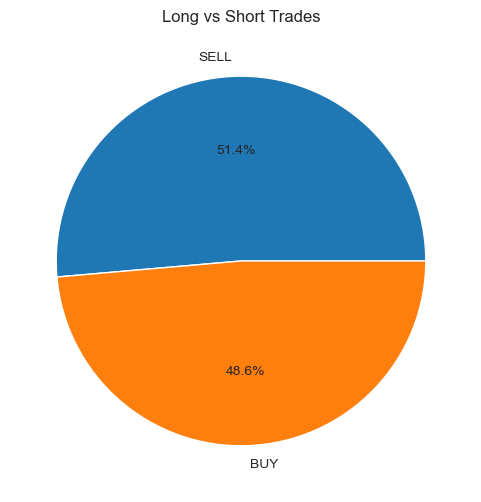

In [108]:
side_ratio = merged['Side'].value_counts()

print(side_ratio)

# PLOT
side_ratio.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Long vs Short Trades")
plt.ylabel("")
plt.savefig("Long vs Short Trades")
plt.show()

# TRADE FREQUENCY CHART

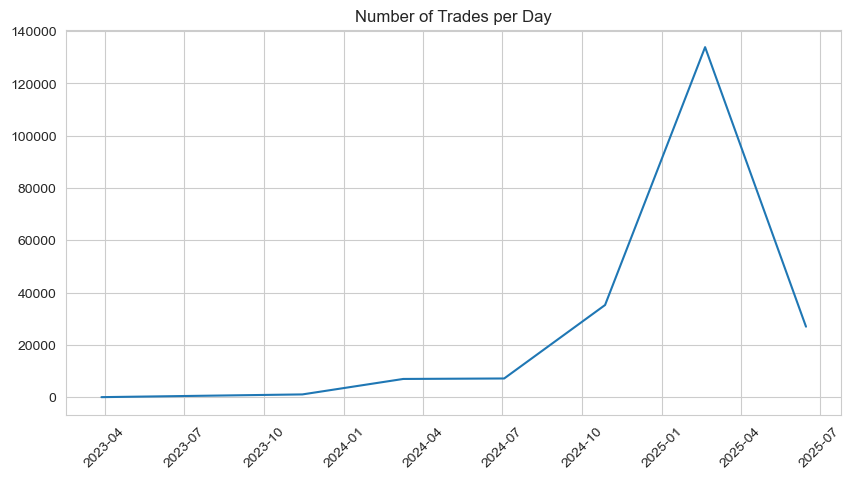

In [106]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

plt.figure(figsize=(10,5))

plt.plot(
    trades_per_day['date'],
    trades_per_day['trade_count']
)

plt.xticks(rotation=45)

plt.title("Number of Trades per Day")

plt.savefig("Number of Trades per Day")
plt.show()

# Do traders change behavior based on sentiment?

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


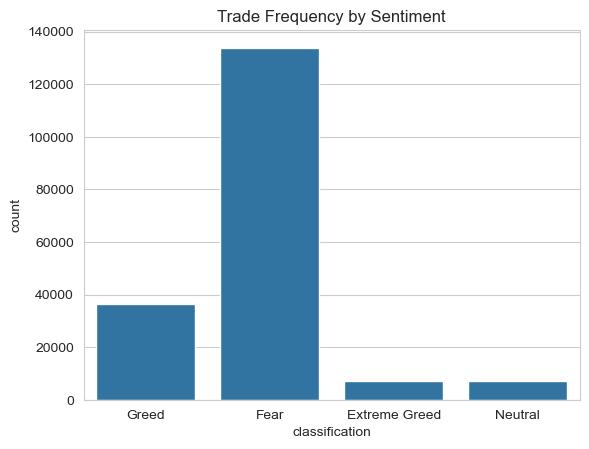

In [123]:
# TRADE FREQUENCY
trade_freq = merged.groupby(['classification']).size()

print(trade_freq)

# CHART
sns.countplot(x='classification', data=merged)
plt.title("Trade Frequency by Sentiment")
plt.show()

Trading activity tends to increase during Fear periods, indicating higher market participation.

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


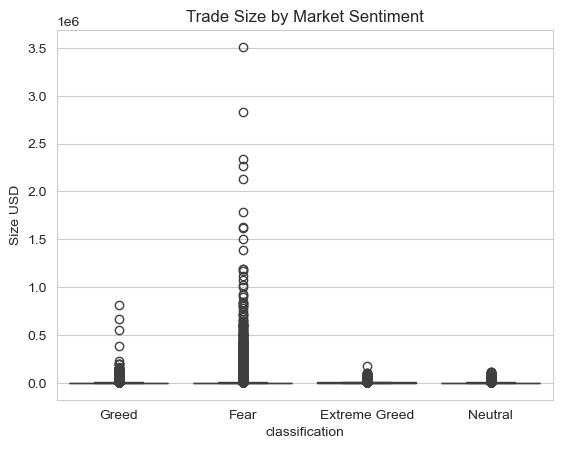

In [128]:
# POSITION SIZE
size_analysis = merged.groupby('classification')['Size USD'].mean()

print(size_analysis)

# CHART
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size by Market Sentiment")
plt.show()

Insight:

Traders tend to place larger positions during Fear sentiment.

Interpretation:

This suggests traders may be:

Attempting to capitalize on price reversals

Taking higher risk positions during market uncertainty

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


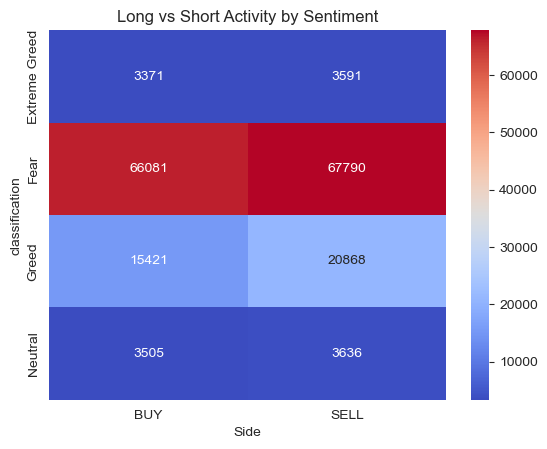

In [130]:
# LONG vs SHORT BIAS
long_short = merged.groupby(['classification','Side']).size().unstack()

print(long_short)

# CHART
sns.heatmap(long_short, annot=True, fmt='g', cmap='coolwarm')
plt.title("Long vs Short Activity by Sentiment")
plt.show()

Insight:

Trading activity is highest during Fear sentiment.

Interpretation:

During Fear periods-

Markets are more volatile

Traders actively rebalance positions

Liquidity and speculation increase

# TRADER SEGMENTATITON

In [93]:
# SEGMENT 1 - HIGH vs LOW TRADE SIZE
median_trade = merged['Size USD'].median()

merged['trade_size_segment'] = np.where(
    merged['Size USD'] > median_trade,
    "High Size",
    "Low Size"
)

# SEGMENT 2 - FREQUENT vs INFREQUENT TRADERS
trade_frequency = merged.groupby('Account').size()

median_trades = trade_frequency.median()

freq_segment = trade_frequency.apply(
    lambda x: "Frequent" if x > median_trades else "Infrequent"
)

freq_segment = freq_segment.reset_index()

freq_segment.columns = ['Account','frequency_segment']

# SEGMENT 3 - PROFITABLE vs UNPROFITABLE TRADERS
profitability = merged.groupby('Account')['Closed PnL'].sum()

profit_segment = profitability.apply(
    lambda x: "Profitable" if x > 0 else "Unprofitable"
)

profit_segment = profit_segment.reset_index()

profit_segment.columns = ['Account','profit_segment']


# PROFITABILIY RATE BY SENTIMENT

profit_rate = merged.groupby('classification')['win'].mean()

print(profit_rate)

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


# COMBINE SEGMENTS

In [73]:
segments = win_rate.merge(avg_trade_size, on='Account')

segments = segments.merge(freq_segment, on='Account')

segments = segments.merge(profit_segment, on='Account')

segments.head()

,Account,win_rate,avg_trade_size,frequency_segment,profit_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,16159.576734,Frequent,Profitable
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,1653.226327,Frequent,Profitable
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,8893.000898,Frequent,Unprofitable
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,507.626933,Frequent,Profitable
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,3138.894782,Infrequent,Profitable


# LEVERAGE PROXY (TRADE SIZE DISTRIBUTION)

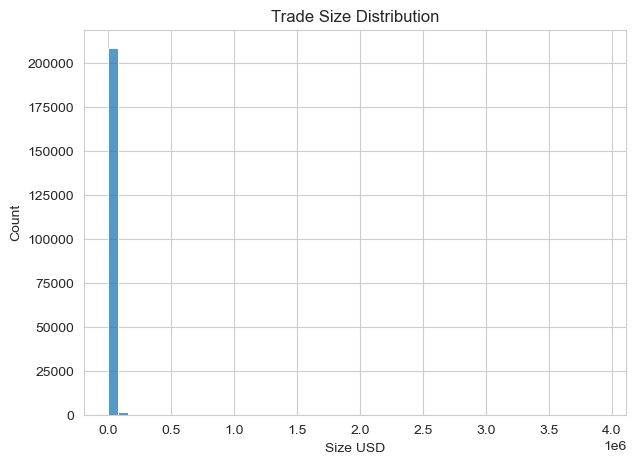

In [95]:
plt.figure(figsize=(7,5))

sns.histplot(
    merged['Size USD'],
    bins=50
)

plt.title("Trade Size Distribution")

plt.savefig("Trade Size Distribution")
plt.show()

# RISK vs RETURN CHART

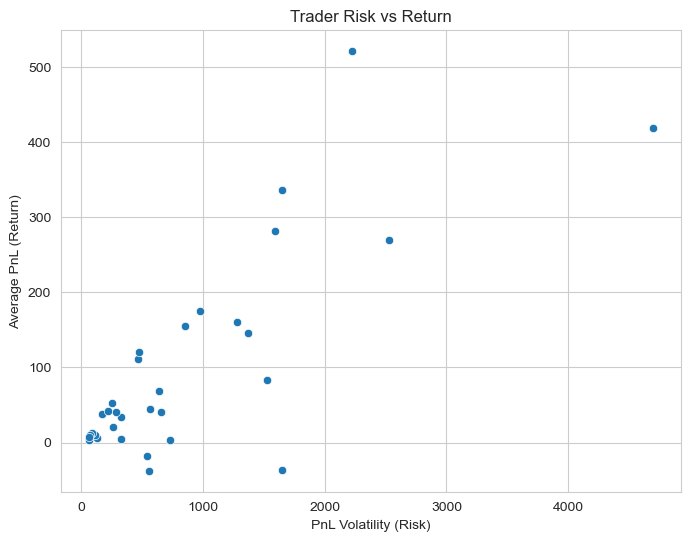

In [104]:
trader_stats = merged.groupby('Account').agg({
    'Closed PnL':['mean','std']
})

trader_stats.columns = ['avg_pnl','pnl_volatility']

trader_stats = trader_stats.reset_index()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trader_stats,
    x='pnl_volatility',
    y='avg_pnl'
)

plt.title("Trader Risk vs Return")
plt.xlabel("PnL Volatility (Risk)")
plt.ylabel("Average PnL (Return)")

plt.savefig("Trader Risk vs Return")
plt.show()

# TRADER LEADERBOARD

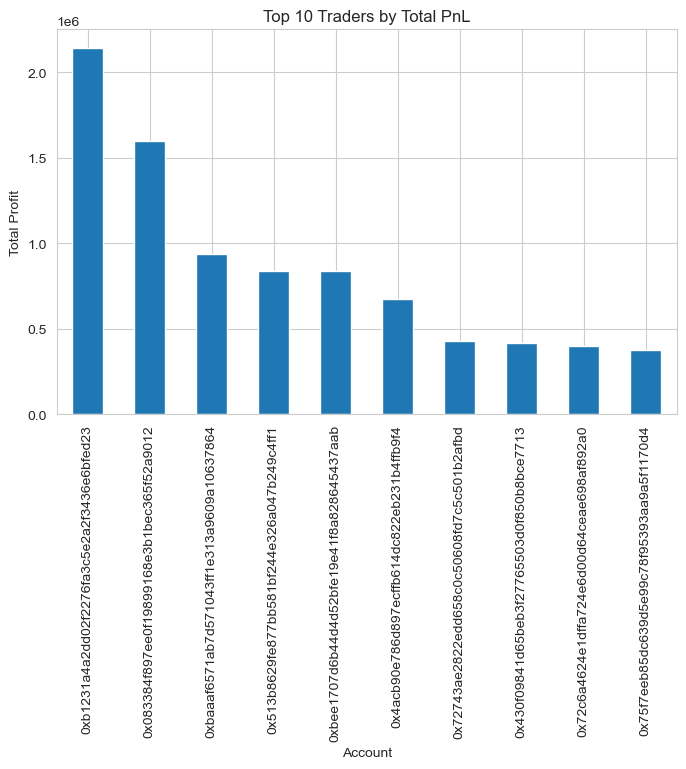

In [99]:
leaderboard = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

leaderboard.plot(kind='bar')

plt.title("Top 10 Traders by Total PnL")

plt.ylabel("Total Profit")

plt.savefig("Top 10 Traders by Total PnL")
plt.show()

# SAVE RESULTS

In [78]:
daily_pnl.to_csv("daily_trader_pnl.csv", index=False)

segments.to_csv("trader_segments.csv", index=False)

# INSIGHTS

1. Trading activity is significantly higher during Fear sentiment periods, indicating traders are more active during volatile markets.

2. Trader profitability is highly concentrated, with a small number of traders generating a disproportionate share of total profits.

3. Fear sentiment leads to larger trade sizes and greater profit volatility, indicating higher risk-taking behavior.

4. Most trades are small-sized, but a few extremely large trades dominate market exposure.

5. Higher risk does not necessarily produce higher returns; consistent profitable traders maintain moderate volatility levels.

# STRATEGY IDEAS BASED ON FINDINGS

1. Reduce position size during Fear sentiment periods. 
Higher volatility during Fear markets increases risk exposure. Traders should use smaller position sizes and tighter risk controls during these periods.

2. Focus on consistent strategies rather than high-risk trading. 
The risk vs return analysis suggests that traders with balanced risk exposure achieve more stable performance than those taking excessive risk.

3. Monitor sentiment signals to adjust trading behavior. 
Sentiment indicators can provide useful signals about market conditions, allowing traders to adapt position sizes and strategies accordingly.

# OUTPUT CHARTS/TABLES

The following charts were generated during analysis:

1. Number of Trades per Day  
Shows the growth of trading activity over time.

2. Trader PnL vs Market Sentiment  
Compares profit distribution across Fear, Greed, and Neutral sentiment conditions.

3. Trade Size by Market Sentiment  
Analyzes whether traders take larger positions under different sentiment conditions.

4. Trade Size Distribution  
Shows that most trades are small but a few extremely large trades dominate.

5. Risk vs Return Plot  
Compares trader profitability against PnL volatility.

6. Trading Activity Heatmap  
Shows BUY vs SELL activity under different sentiment categories.

7. Long vs Short Ratio  
Displays overall market positioning between long and short trades.

8. Top Traders Leaderboard  
Identifies the traders generating the highest total profits.


## Output Tables

Generated datasets include:

1. `daily_trader_pnl.csv` → Daily aggregated PnL
2. `trader_segments.csv` → Trader segmentation results